# Understand the dataset

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRFRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/prevek18/ames-housing-dataset/AmesHousing.csv')

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
df.shape

(2930, 82)

In [7]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [9]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


# Data Cleaning

In [10]:
# Missing percentage of all features

missing = df.isnull().sum()

print((missing[missing > 0].sort_values(ascending=False)/df.shape[0]) *100)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop(columns=['Order','PID','Pool QC','Misc Feature','Alley','Fence','Mas Vnr Type','Fireplace Qu'],axis = 1, inplace=True)

In [13]:
df.shape

(2930, 74)

In [14]:
numeric_col = df.select_dtypes(include='number').columns

missing = df[numeric_col].isnull().sum()
filter_missing  = missing[missing > 0] 

for col in filter_missing.index:
   df[col] = df[col].fillna(df[col].mean())

In [15]:
cat_col = df.select_dtypes(include='object').columns

missing = df[cat_col].isnull().sum()
filter_missing  = missing[missing > 0] 

for col in filter_missing.index:
   df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [31]:
df.loc[df['Garage Yr Blt'] > 2026, 'Garage Yr Blt'] = np.nan

df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Garage Yr Blt'].median())

# Exploratory Data Analysis(EDA)

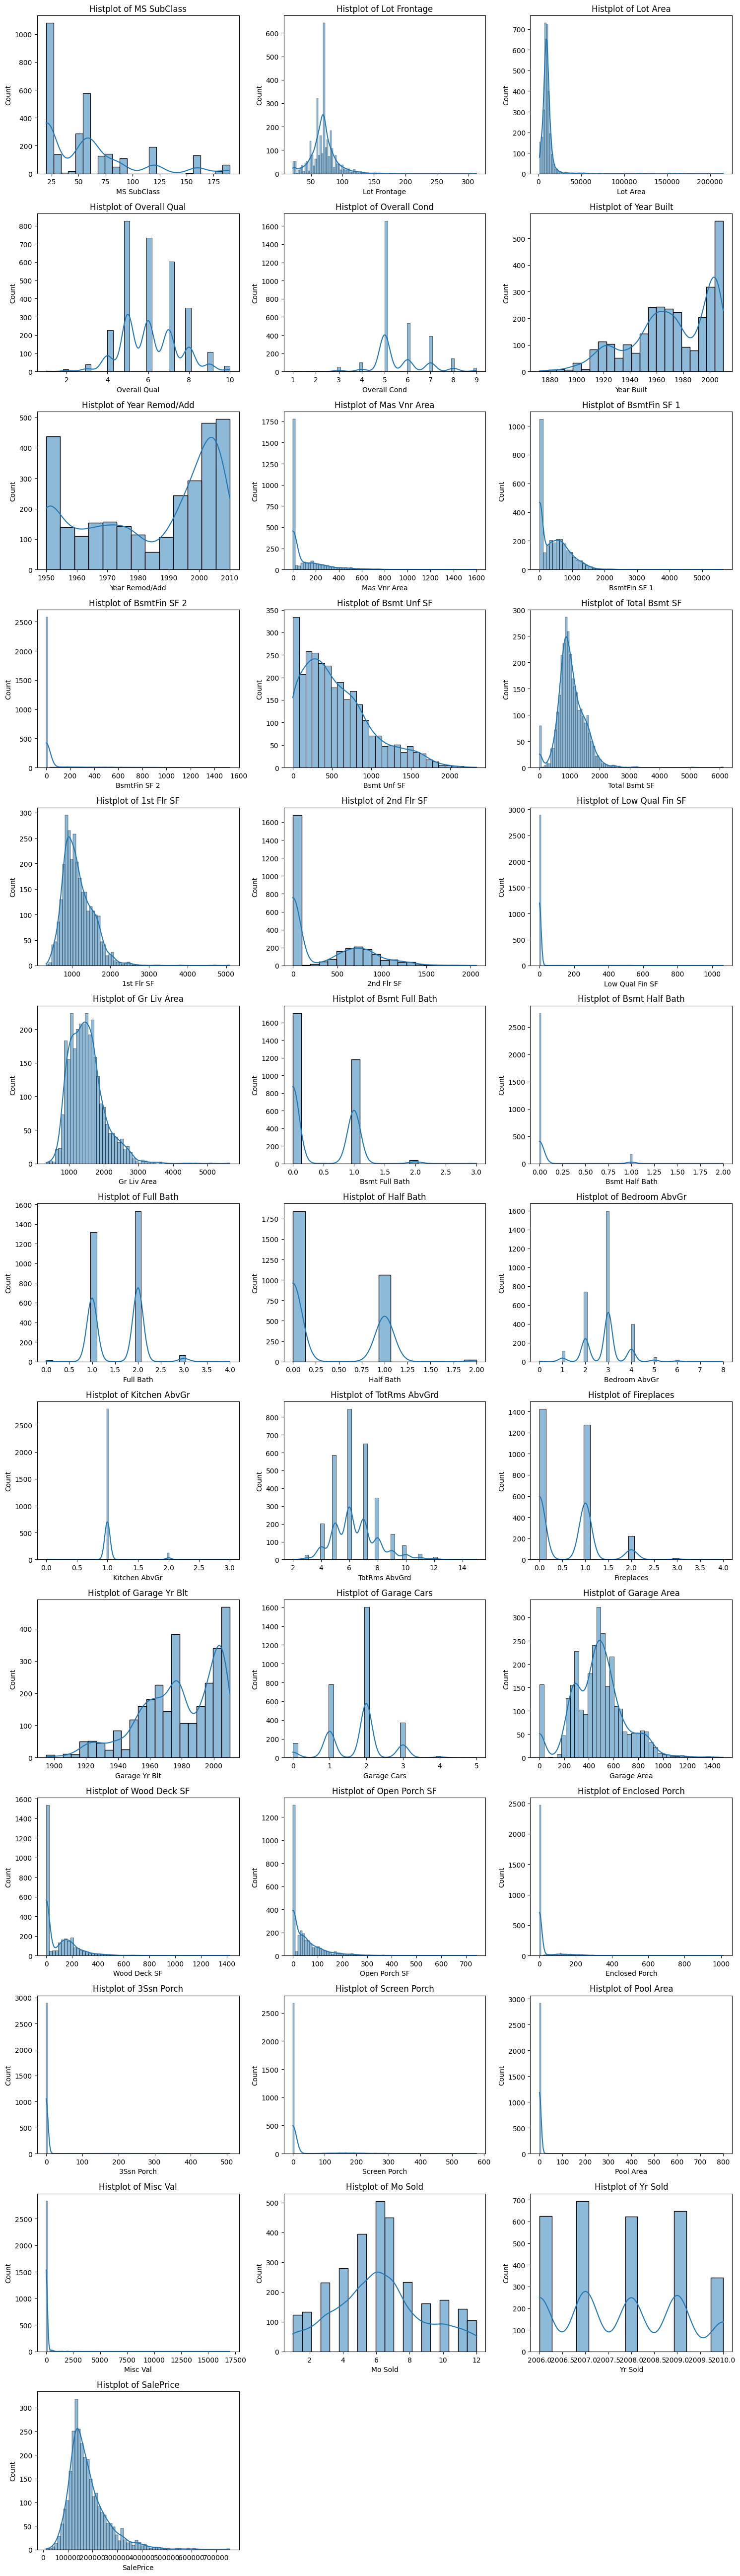

In [44]:
import math

numeric_col = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numeric_col):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histplot of {col}')

plt.tight_layout()
plt.show()

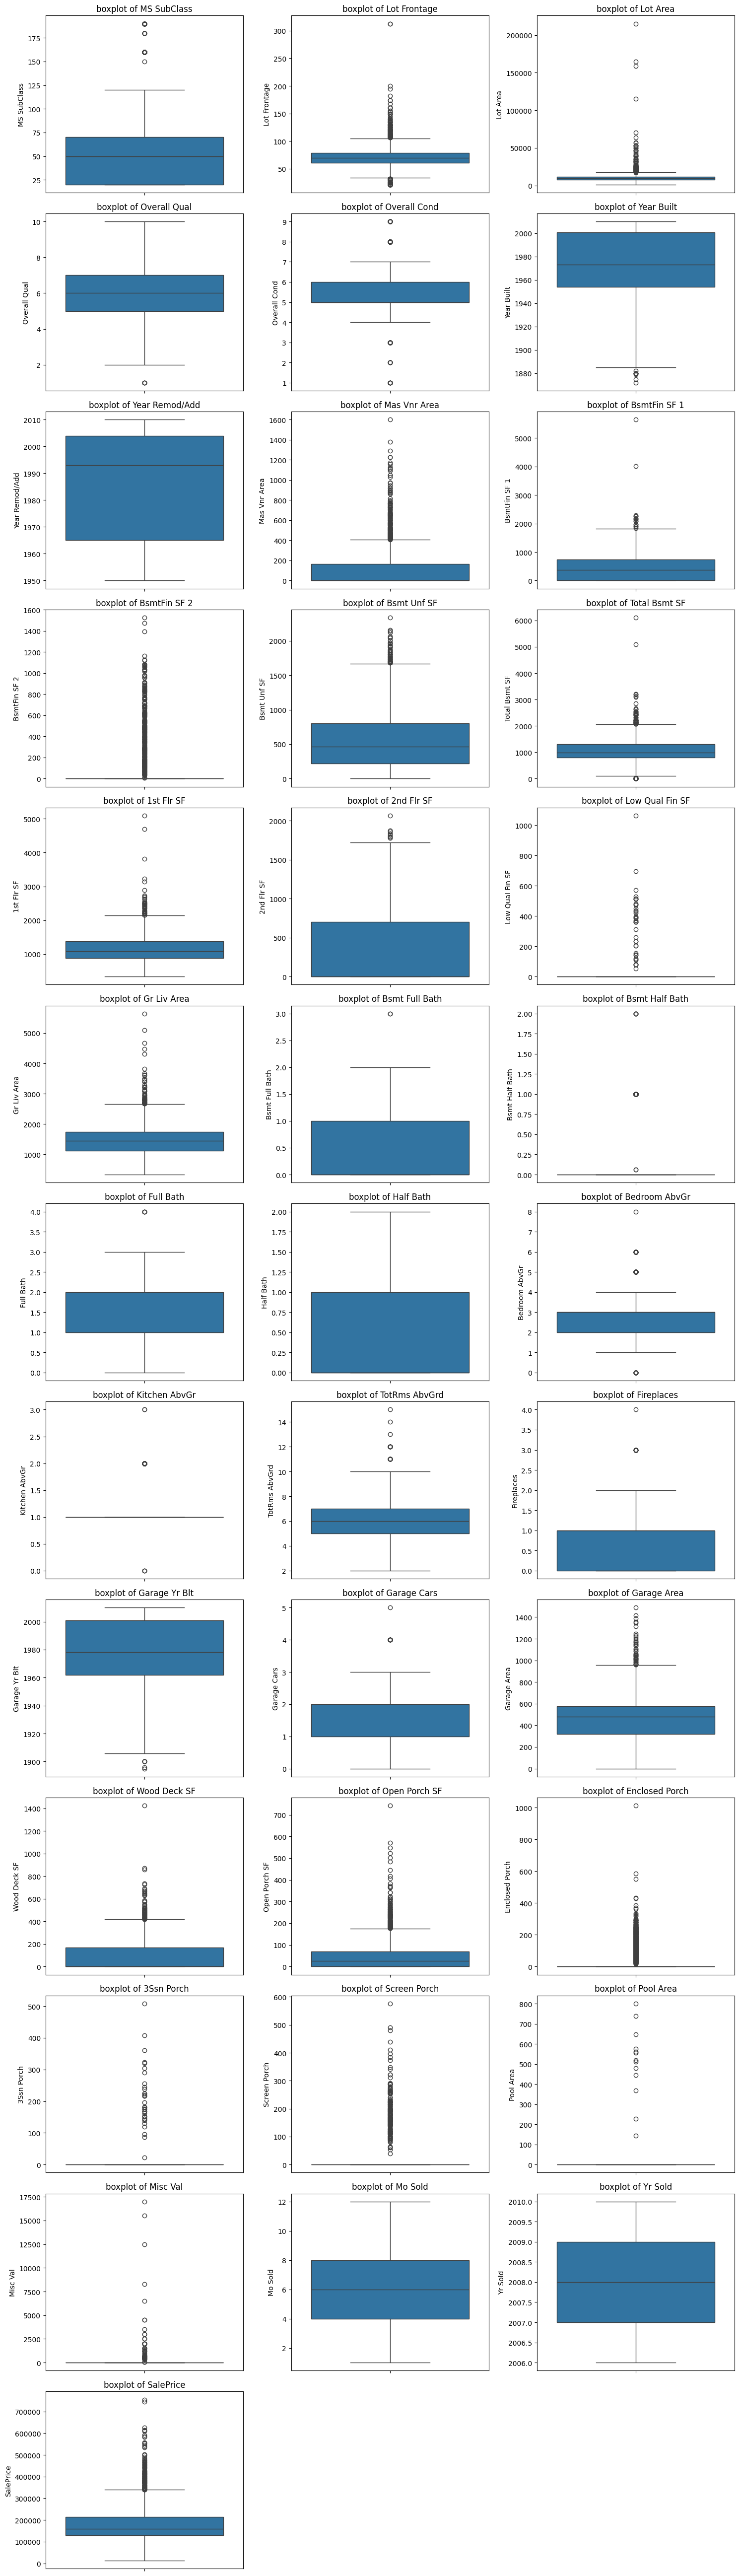

In [33]:
import math

numeric_col = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numeric_col):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(df[col])
    plt.title(f'boxplot of {col}')

plt.tight_layout()
plt.show()

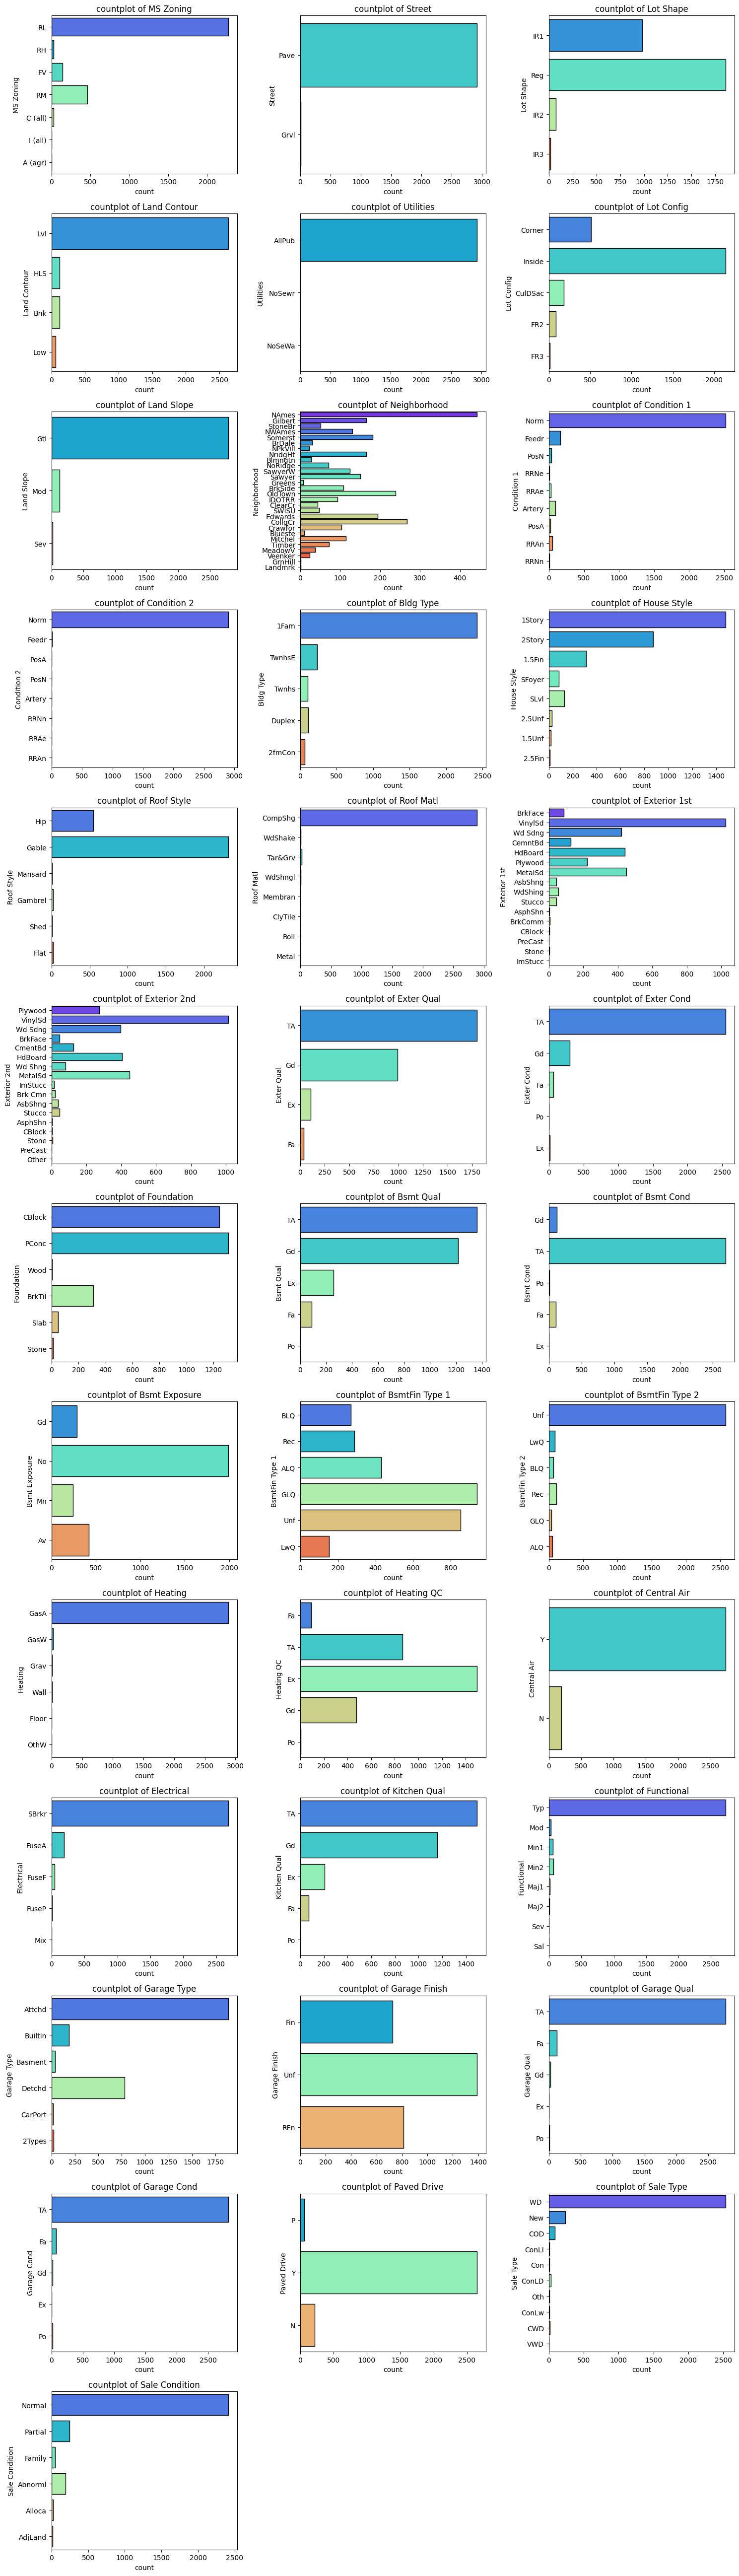

In [48]:
import math

cat_col = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = math.ceil(len(cat_col) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numeric_col):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(df[col], palette ='rainbow', edgecolor='black')
    plt.title(f'countplot of {col}')

plt.tight_layout()
plt.show()

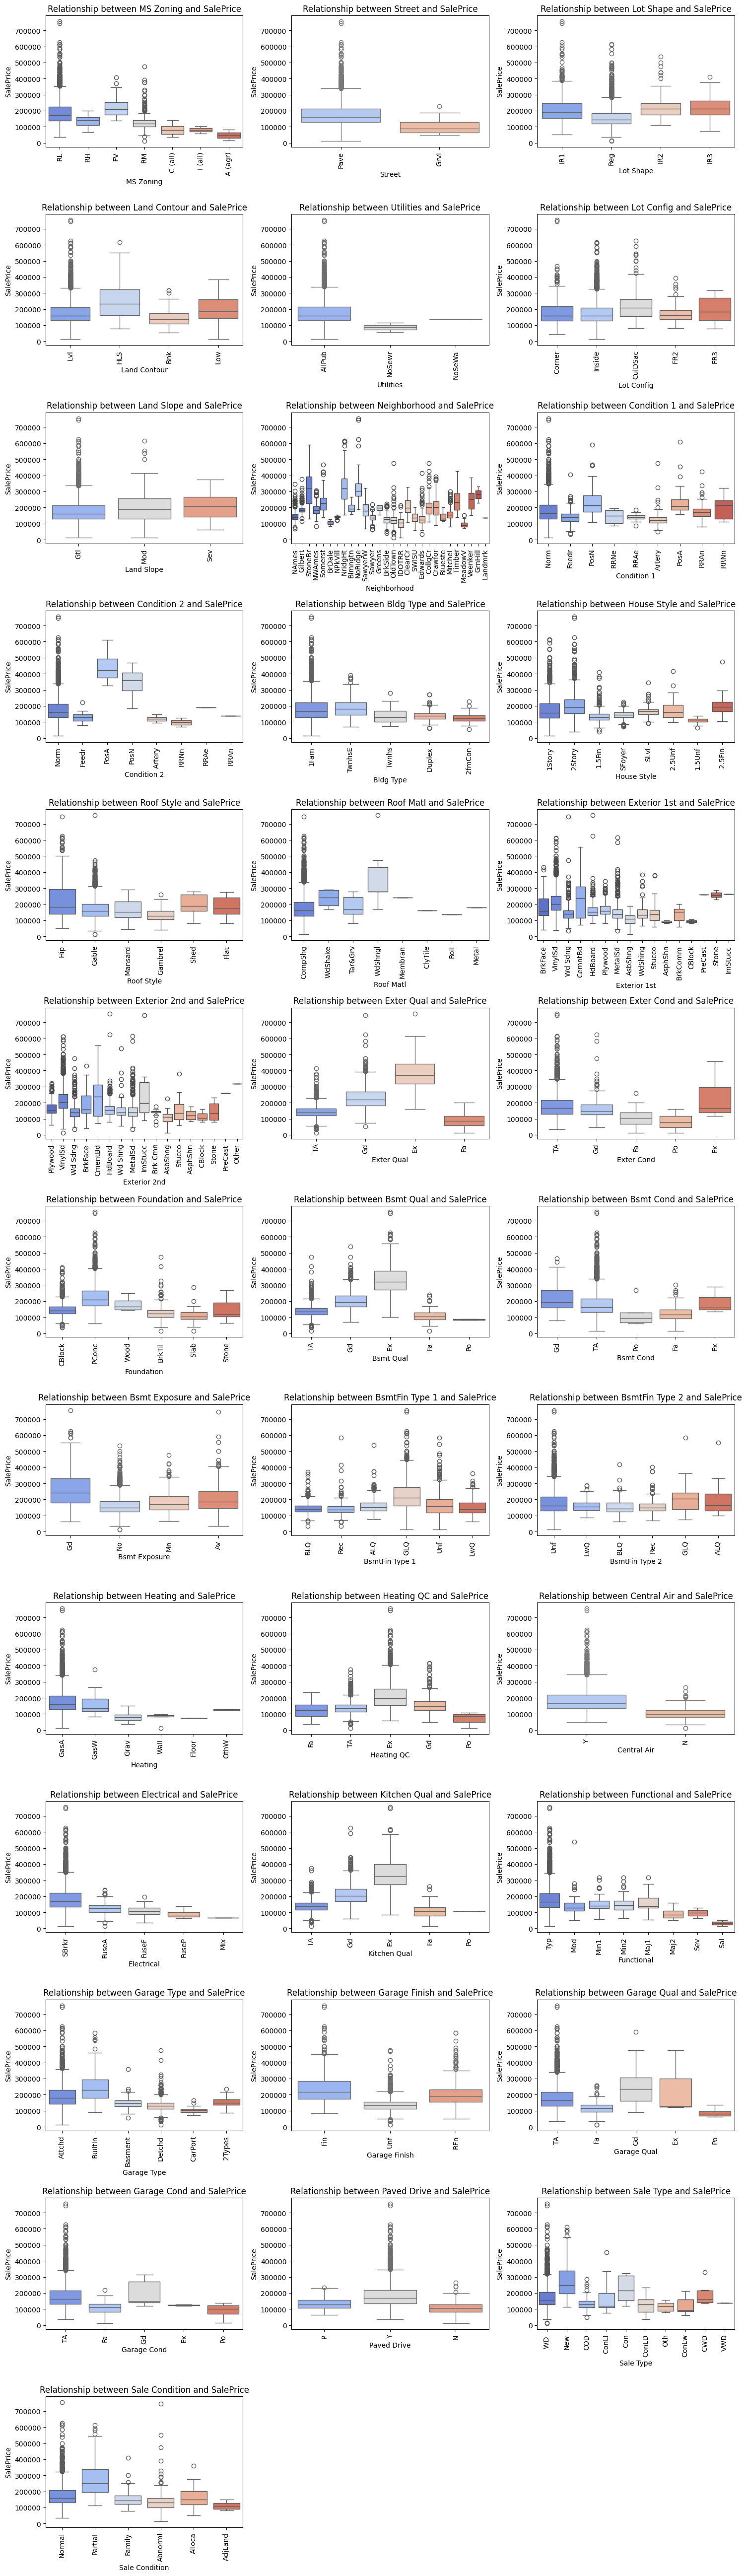

In [47]:
import math

numeric_col = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numeric_col):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data = df, x = col, y = 'SalePrice', palette='coolwarm')
    plt.title(f'Relationship between {col} and SalePrice')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

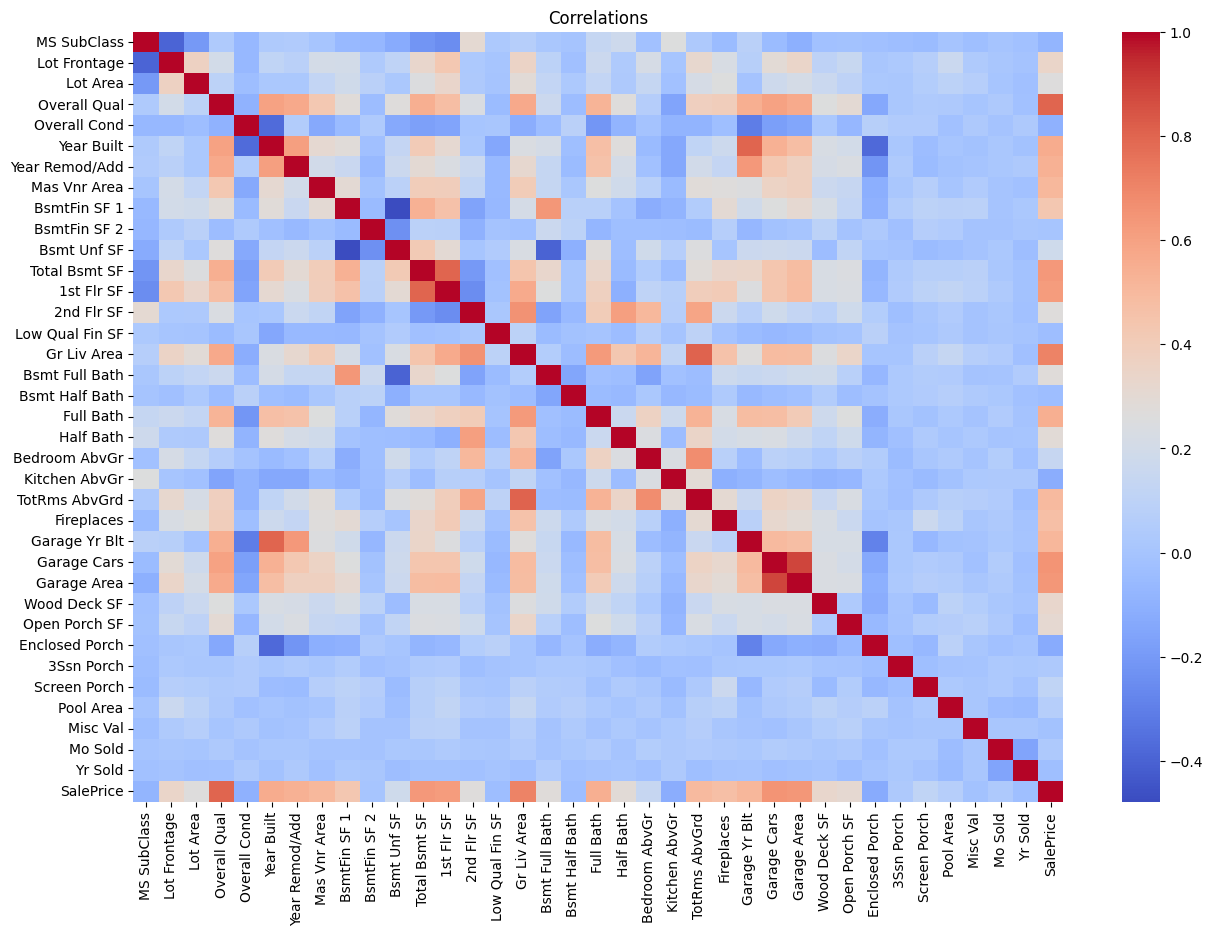

In [55]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(15,10))
sns.heatmap( corr, cmap='coolwarm')
plt.title('Correlations')
plt.show()

# Feature Engineering

In [56]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,0,3,2010,WD,Normal,189900


**1. House and Garage Features**

In [57]:
df['House Age'] = df['Yr Sold'] - df['Year Built']
df['Remod Age'] = df['Yr Sold'] - df['Year Built']
df['Garage Age'] = df['Yr Sold'] - df['Garage Yr Blt']

**2. Total Area , Quality and Bath Feature**

In [58]:
df['Total SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['Overall Score'] = df['Overall Qual'] * df['Overall Cond']

df['Total Bath'] = (
    df['Full Bath'] +
    0.5 * df['Half Bath'] +
    df['Bsmt Full Bath'] +
    0.5 * df['Bsmt Half Bath']
)

In [60]:
df.shape

(2930, 80)

# Preprocessing Data

***Now we are going to convert the categorical data into numeric, with the help of Label-Encoder***

In [62]:
categorical_col = df.select_dtypes(include='object')

for col in categorical_col:
    encoder = LabelEncoder()
    
    df[col] = encoder.fit_transform(df[col])

In [64]:
df.head(3)

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,House Age,Remod Age,Garage Age,Total SF,Overall Score,Total Bath
0,20,5,141.0,31770,1,0,3,0,0,0,15,2,2,0,2,6,5,1960,1960,3,1,3,10,112.0,3,4,1,4,2,1,1,639.0,5,0.0,441.0,1080.0,1,1,1,4,1656,0,0,1656,1.0,0.0,1,0,3,1,4,7,7,2,1,1960.0,0,2.0,528.0,4,4,1,210,62,0,0,0,0,0,5,2010,9,4,215000,50,50,50.0,2736.0,30,2.0
1,20,4,80.0,11622,1,3,3,0,4,0,15,1,2,0,2,5,6,1961,1961,1,1,13,14,0.0,3,4,1,4,4,3,4,468.0,3,144.0,270.0,882.0,1,4,1,4,896,0,0,896,0.0,0.0,1,0,2,1,4,5,7,0,1,1961.0,2,1.0,730.0,4,4,2,140,0,0,0,120,0,0,6,2010,9,4,105000,49,49,49.0,1778.0,30,1.0
2,20,5,81.0,14267,1,0,3,0,0,0,15,2,2,0,2,6,6,1958,1958,3,1,14,15,108.0,3,4,1,4,4,3,0,923.0,5,0.0,406.0,1329.0,1,4,1,4,1329,0,0,1329,0.0,0.0,1,1,3,1,2,6,7,0,1,1958.0,2,1.0,312.0,4,4,2,393,36,0,0,0,0,12500,6,2010,9,4,172000,52,52,52.0,2658.0,36,1.5


# Cross Validation

In [65]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
voting = VotingRegressor(
    estimators = [
        ('RF', RandomForestRegressor(random_state=42)),
        ('CAT', CatBoostRegressor(random_state=42,verbose=0)),
        ('LGBM',LGBMRegressor(random_state=42,verbose=-1)),
        ('XGB', XGBRFRegressor(random_state=42))
    ]
)

models = {
    'RF': RandomForestRegressor(random_state=42),
    'CAT': CatBoostRegressor(random_state=42,verbose=0),
    'LGBM':LGBMRegressor(random_state=42,verbose=-1),
    'XGB':XGBRFRegressor(random_state=42),
    'VOTING' : voting
}

for name,model in models.items():
    scores = cross_val_score(
        estimator=model,
        X = X,
        y = y,
        scoring= 'r2',
        cv= 5
    )
    
    print('-*'*20, name, '-*'*20)
    print('CV Scores:', scores)
    print('Mean Score:', np.mean(scores))

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* RF -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
CV Scores: [0.91348815 0.92511133 0.89541191 0.85001448 0.91744028]
Mean Score: 0.9002932316612842
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* CAT -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
CV Scores: [0.93045256 0.94486951 0.92696945 0.86434909 0.93652363]
Mean Score: 0.9206328507689034
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* LGBM -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
CV Scores: [0.9172397  0.93392794 0.91182431 0.85692216 0.92876662]
Mean Score: 0.9097361448063654
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* XGB -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
CV Scores: [0.89321065 0.90234828 0.87279749 0.83688724 0.89853895]
Mean Score: 0.8807565212249756
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* VOTING -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
CV Scores: [0.92273013 0.93682006 0.91315117 0.86281805 0.93058325]
Mean Score: 0.9132205312184005



**🏆 Final Choice: CatBoost**

**We select CatBoostRegressor as the final model because it achieved the highest CV score (0.921) and shows strong, consistent performance across folds. It also handles categorical features efficiently and performs better than the ensemble models in this case.**


In [109]:
final_model = CatBoostRegressor(
    iterations=800,
    learning_rate= 0.05,
    depth = 6,
    l2_leaf_reg= 5,
    verbose=0,
    random_state = 42
)

final_model.fit(X_train, y_train)

final_model.score(X_train, y_train), final_model.score(X_test, y_test)

(np.float64(0.9869933654056866), np.float64(0.929554860577524))

**Hyperparameter tuning best features wasn't proving us a perfect result. So we change the parameter menually**

# Hyperparameter tuning

**In here we can witness that, there is a small overfitting in our model. So therefore, we have to tune the model, to make it more perfect.**

In [91]:
params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
    'iterations': [300, 500, 700, 1000],
    'l2_leaf_reg': [1, 3, 5, 7]
}

In [94]:
tuning = RandomizedSearchCV(
    estimator = final_model,
    param_distributions= params,
    scoring= 'r2',
    cv = 5,
    random_state= 42
)

tuning.fit(X_train, y_train)

print('Best Features:', tuning.best_params_)
print('Best Score:', tuning.best_score_)

Best Features: {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 1000, 'depth': 8}
Best Score: 0.9139322044841418


# Model Evaluation

In [110]:
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

n = X_train.shape[0]
p = X_train.shape[1]

adjusted = 1 - ((r2-1)*(1-n)/(n-p-1))

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {np.sqrt(mse)}')
print(f'R2-Score: {r2}')
print(f'Adjustd R2-Score: {adjusted}')

MAE: 13632.019280613085
MSE: 564797281.8191813
RMSE: 23765.464056466084
R2-Score: 0.929554860577524
Adjustd R2-Score: 0.9270967483803616


# Feature Importance

In [148]:

importance = final_model.feature_importances_

dataset = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance',ascending=False)


print('Total Importance :',dataset['Importance'].head(18).sum(),'%\n')

dataset.head(18).reset_index(drop=True)

Total Importance : 80.39216141447959 %



,Feature,Importance
0,Total SF,21.532100
1,Overall Qual,13.752414
2,Gr Liv Area,5.407261
3,Remod Age,5.340794
4,Overall Score,4.456015
5,Fireplaces,3.609177
6,Total Bath,3.602260
7,Lot Area,3.270626
8,BsmtFin SF 1,2.323258
9,Kitchen Qual,2.234196


In [152]:
import joblib

print(joblib.dump(final_model, 'cat_model.pkl'))
print(joblib.dump(X.columns.tolist(), 'features.pkl'))
print(joblib.dump(encoder, 'label_encoder.pkl'))
print(joblib.dump(df, 'dataset.pkl'))

['cat_model.pkl']
['features.pkl']
['label_encoder.pkl']
['dataset.pkl']
